# Saving data from DHT11 temperature sensor into a CSV file

You can use that CSV file to do further analysis with your data at a later time. This will be very useful for your long assignment!


In [1]:
# import all the needed libraries 
from Arduino import Arduino
import time
import serial
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython import display

In [ ]:
# Noah's homemade herbs and spices, be careful: 
# https://stackoverflow.com/questions/24214643/python-to-automatically-select-serial-ports-for-arduino

import warnings
import serial
import serial.tools.list_ports

arduino_ports = [
    p.device
    for p in serial.tools.list_ports.comports()
    if 'Arduino' in p.description  # may need tweaking to match new arduinos
]
if not arduino_ports:
    raise IOError("No Arduino found")
if len(arduino_ports) > 1:
    warnings.warn('Multiple Arduinos found - using the first')

ser = serial.Serial(arduino_ports[0])

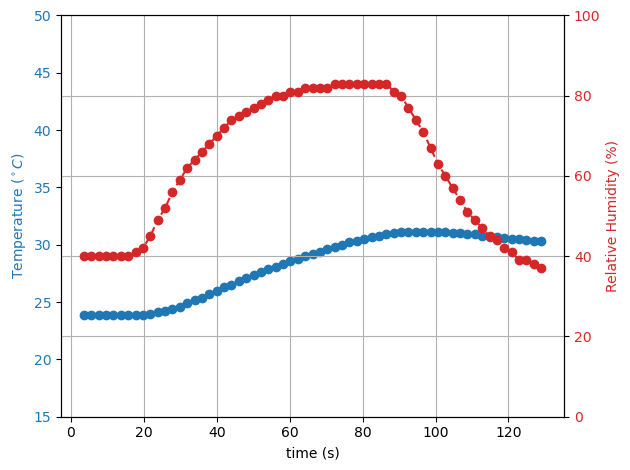

In [ ]:
PORT_NAME = 'COM5'                        # example of Windows port name
# PORT_NAME = '/dev/cu.usbmodem1101'      # example of Mac port name 

# get current date and time into a string
timestr = time.strftime("%Y%m%d-%H%M%S")

# define csv file name based on current data and time, so you don't lose track of when you took your data
FILE_NAME = 'DHT11_data_'+timestr+'.csv'    

# first row of your data are column names
data = np.array(['Counter', 'Time (s)', 'Temperature (C)','Relative Humidity (%)'])    

# initialize empty list for plotting later
time_array = np.array([])            # time data
temperature_array = np.array([])     # temperature data
rh_array = np.array([])              # relative humidity data

# to count how many data-points we have collected
counter = 0

# capture current time as datum
startTime = time.time() 

try:
    #open the serial port to Arduino
    arduino = serial.Serial(PORT_NAME, 9600)

    while True:
        # reads the sensor data from arduino via serial port
        arduino_data = arduino.readline() 

        # deals with the odd way the data are presented to the serial port
        decoded_values = arduino_data.decode("utf-8").split('x') 
        temperature = float(decoded_values[0])
        rh = float(decoded_values[1])

        # time at which data was collected from sensor
        time_stamp = time.time()-startTime 
        
        # write list of data to file
        new_data = np.array([counter, time_stamp, temperature, rh])
        data = np.vstack([data, new_data])  # vstack is similar to np.append but adds the array as a new row instead
        
        # add new data to our arrays
        time_array = np.append(time_array, time_stamp)
        temperature_array = np.append(temperature_array, temperature)
        rh_array = np.append(rh_array, rh)

        # update counter   
        counter += 1

        # plot temperature data "live" as it is recorded 
        fig, ax = plt.subplots()
        color = 'tab:blue'
        ax.plot(time_array, temperature_array, marker='o', linestyle='--', color=color)
        ax.set_ylabel("Temperature ($^\\circ C$)", color=color)
        ax.set_ylim([15,50])
        ax.grid(visible=True, axis='x')
        ax.tick_params(axis='y', labelcolor=color)
        ax.set_xlabel('time (s)')

        # plot relative humidity data on the same plot but with its own y-axis
        ax2 = ax.twinx()
        color = 'tab:red'
        ax2.plot(time_array, rh_array, marker='o', linestyle='--', color=color)
        ax2.set_xlabel("Time (s)")
        ax2.set_ylabel("Relative Humidity (%)", color=color)
        ax2.set_ylim([0,100])
        ax2.grid(visible=True) 
        ax2.tick_params(axis='y', labelcolor=color)           
        fig.tight_layout()

        # Animation commands to update plot 
        display.clear_output(wait=True)     # necessary to not create a new figure at every iteration
        display.display(plt.gcf())          # necessary to keep the figure displayed in the notebook after every iteration
        # time.sleep(0.05)                  # only necessary if data generated too quickly in loop  
        plt.close()
    
except KeyboardInterrupt:

    # save your data to a CSV file
    df = pd.DataFrame(data)      # first convert our Numpy array into a Pandas dataframe (like a spreadsheet)
    df.to_csv(FILE_NAME, index=False, header=False)  # export that dataframe to a CSV file
    arduino.close()   # close board connection
    

# Importing CSV file using Python

This code will allow you to import data in CSV file you saved previously using the above code. Read the comments carefully, all the instructions are there.

In [ ]:
FILE_NAME = 'DHT11_data_20251017-165528.csv'

# read the CSV file into a dataframe (i.e. like a Python spreadsheet)
df = pd.read_csv(FILE_NAME)

# convert dataframe into a 2D Numpy array
a = df.to_numpy()

# the first column are the counters
counter_array = a[:,0]

# the second column are the time stamps
time_stamp_array = a[:,1]

# the third column are your measurements: either pulseTime or distance depending on how you modified the code above
temperature_array = a[:,2]

# the third column are your measurements: either pulseTime or distance depending on how you modified the code above
rh_array = a[:,3]

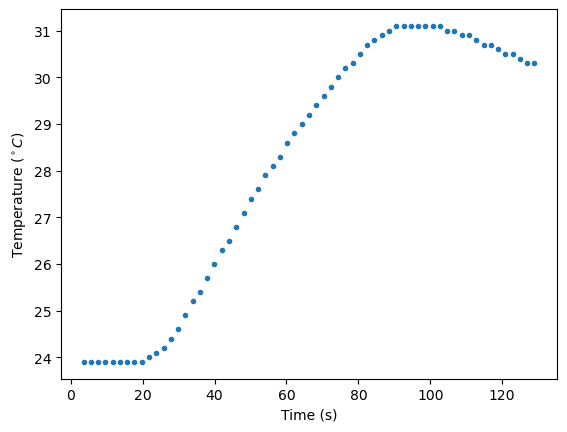

In [9]:
### plot temperature
plt.plot(time_stamp_array, temperature_array, ".")
plt.xlabel("Time (s)")
plt.ylabel("Temperature ($^\\circ C$)")            
plt.show()